In [1]:
import sys
import git
import pathlib

# Set up the PROJ_ROOT variable
PROJ_ROOT_PATH = pathlib.Path(git.Repo('.', search_parent_directories=True).working_tree_dir)
PROJ_ROOT =  str(PROJ_ROOT_PATH)
if PROJ_ROOT not in sys.path:
    sys.path.append(PROJ_ROOT)

# Explicitly add the current notebook's directory
CURRENT_DIR = str(pathlib.Path().absolute())
if CURRENT_DIR not in sys.path:
    sys.path.insert(0, CURRENT_DIR)

In [2]:
import numpy as np
from scipy.constants import pi

In [8]:
# resistivity above 4K
# 2025raicuCryogenicThermalModeling

def rho_hdw_high(T):
    # Units = W/m.K
    # Assuming RRR = 50
    a = -8.327
    b = 10.012
    c = -52.833
    d = 122.547
    e = -152.760
    f = 109.033
    g = -44.416
    h = 9.598
    i = -0.854

    rho_hdw = 10**(
        a 
        + b*(np.log10(T)) 
        + c*(np.log10(T))**2
        + d*(np.log10(T))**3
        + e*(np.log10(T))**4
        + f*(np.log10(T))**5
        + g*(np.log10(T))**6
        + h*(np.log10(T))**7
        + i*(np.log10(T))**8
    )

    return rho_hdw

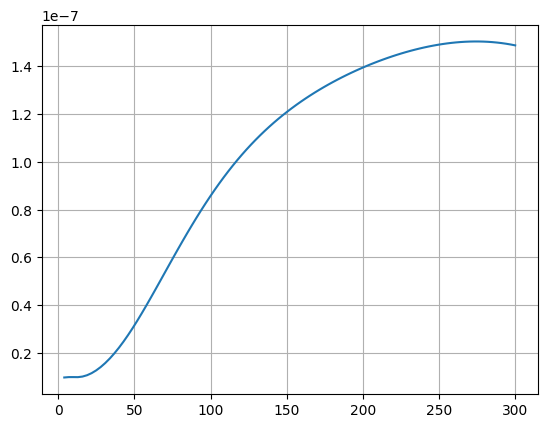

In [10]:
import matplotlib.pyplot as plt
temp = np.linspace(4, 300, num=100)
values = rho_hdw_high(temp)
plt.plot(temp, values)
plt.grid(True)

In [14]:
from scipy.integrate import quad
import math
# Integrate rho_hdw_high from 300K to 50K
T_300K = 300
T_50K = 50
rho_eqv, error = quad(rho_hdw_high, T_50K, T_300K)
print(f"The numerical result is {rho_eqv:.6f} (+-{error:.10g})")

The numerical result is 0.000029 (+-6.260267739e-15)


In [15]:
diam = 0.203E-3
area = pi * (diam/2)**2
l_50K = 0.3053
R_50K = rho_eqv * l_50K / area
print(f"{R_50K=}")

R_50K=278.1642398998726


In [16]:
rho_hdw = 9.928E-9 #ohm-meter
l_4K = 0.3155
l_Still = 0.2755
l_CP = 0.1965
l_MXC = 0.1965

diam = 0.203E-3
area = pi * (diam/2)**2

In [4]:
R_4K = rho_hdw * l_4K / area
print(f"{R_4K=}")

R_Still = rho_hdw * l_Still / area
print(f"{R_Still=}")

R_CP = rho_hdw * l_CP / area
print(f"{R_CP=}")

R_MXC = rho_hdw * l_MXC / area
print(f"{R_MXC=}")

R_4K=0.09677856424910175
R_Still=0.08450869873416017
R_CP=0.06027571434215054
R_MXC=0.06027571434215054
